In [1]:
# ============================================================
# Imports & Configuration
# ============================================================

import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import matplotlib.pyplot as plt
from skimage import data as skdata
from skimage.color import rgb2gray
from skimage.transform import resize

from src.operators import MeasurementOperator
from src.admm import admm_solve
from src.svt import effective_rank
from src.metrics import relative_error, psnr, ssim, print_metrics
from config import RHO, MAX_ITER, TOL, RANDOM_SEED

%matplotlib inline
plt.rcParams['figure.dpi'] = 120
plt.rcParams['image.cmap'] = 'gray'

# 1. Load and prepare a natural camera image
We use scikit-image's built-in 'camera' image (a 512×512 greyscale photograph of a cameraman)
as a generalisation test. Unlike the Shepp-Logan phantom, this is a natural image with much 
richer structure - its singular values decay more slowly and it is far from low-rank. 
This tests the limits of the nuclear norm minimisation approach.

In [2]:
IMAGE_SIZE = 64   # resize to keep computation tractable

# Load, convert to greyscale, resize, normalise to [0, 1]
cam_raw  = skdata.camera()                        # 512x512, uint8
cam_gray = cam_raw.astype(np.float64) / 255.0    # normalise
X_true   = resize(cam_gray, (IMAGE_SIZE, IMAGE_SIZE), anti_aliasing=True)
X_true   = np.clip(X_true, 0.0, 1.0)

sigma     = np.linalg.svd(X_true, compute_uv=False)
eff_rank  = np.sum(sigma > sigma[0] * 1e-3)
rank_full = np.linalg.matrix_rank(X_true)

print(f"Image shape     : {X_true.shape}")
print(f"Value range     : [{X_true.min():.4f}, {X_true.max():.4f}]")
print(f"Full rank       : {rank_full}")
print(f"Effective rank  : {eff_rank}  (singular values > 0.1% of largest)")

total_energy = np.sum(sigma**2)
print("\nEnergy captured by top-k singular values:")
for k in [5, 10, 20, 30, 50]:
    energy = np.sum(sigma[:k]**2) / total_energy
    print(f"  top-{k:3d} : {energy*100:.1f}%")

Image shape     : (64, 64)
Value range     : [0.0150, 0.9191]
Full rank       : 64
Effective rank  : 46  (singular values > 0.1% of largest)

Energy captured by top-k singular values:
  top-  5 : 98.8%
  top- 10 : 99.6%
  top- 20 : 99.9%
  top- 30 : 100.0%
  top- 50 : 100.0%


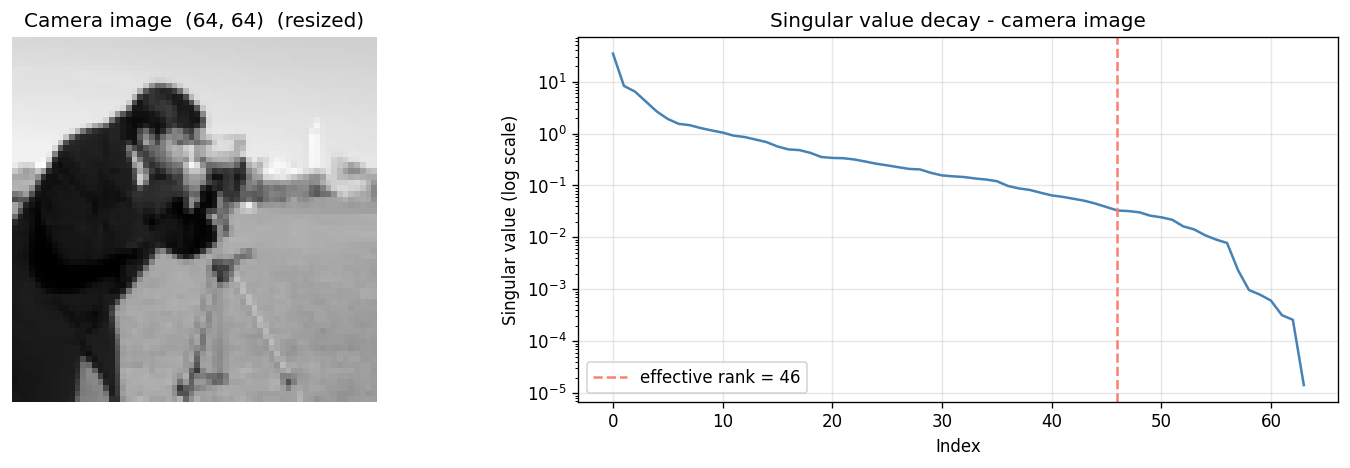

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].imshow(X_true, cmap='gray')
axes[0].set_title(f"Camera image  {X_true.shape}  (resized)")
axes[0].axis('off')

axes[1].semilogy(sigma, color='steelblue', linewidth=1.5)
axes[1].axvline(x=eff_rank, color='salmon', linestyle='--',
                label=f'effective rank = {eff_rank}')
axes[1].set_title("Singular value decay - camera image")
axes[1].set_xlabel("Index")
axes[1].set_ylabel("Singular value (log scale)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 2. Compare singular value decay: toy vs Shepp-Logan vs camera
This directly motivates why recovery difficulty varies across the three settings.

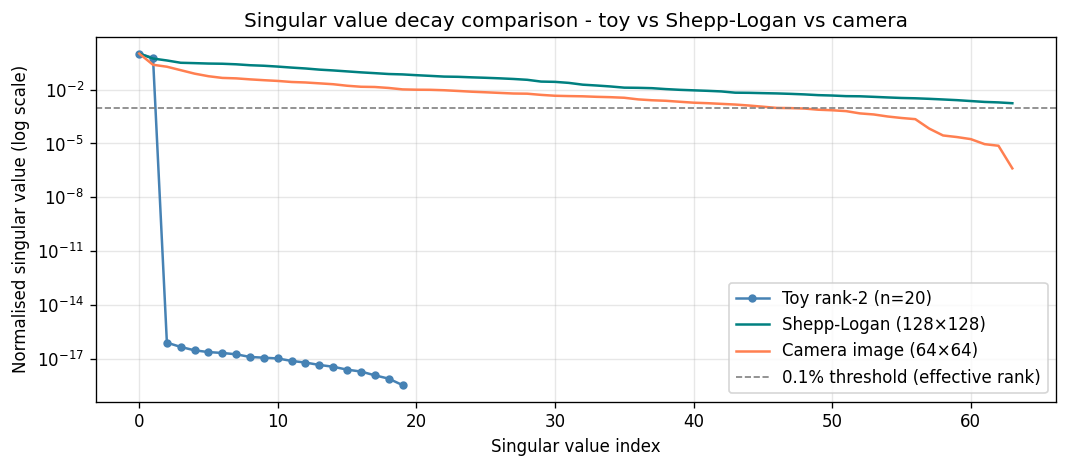

Effective ranks:
  Toy rank-2     : 2
  Shepp-Logan    : 64
  Camera image   : 46


In [4]:
# Load Shepp-Logan for comparison
from config import SHEPP_LOGAN_PATH, IMAGE_SIZE as SL_SIZE
X_sl = np.load(SHEPP_LOGAN_PATH)
sig_sl = np.linalg.svd(X_sl, compute_uv=False)

# Toy rank-2 matrix
rng    = np.random.default_rng(42)
U_toy  = rng.standard_normal((20, 2))
V_toy  = rng.standard_normal((20, 2))
X_toy  = U_toy @ V_toy.T
sig_toy = np.linalg.svd(X_toy, compute_uv=False)
sig_toy_norm = sig_toy / sig_toy[0]   # normalise for comparison

sig_sl_norm  = sig_sl[:IMAGE_SIZE] / sig_sl[0]
sig_cam_norm = sigma[:IMAGE_SIZE] / sigma[0]

plt.figure(figsize=(9, 4))
plt.semilogy(sig_toy_norm, 'o-', color='steelblue', markersize=4,
             linewidth=1.5, label='Toy rank-2 (n=20)')
plt.semilogy(sig_sl_norm, color='teal', linewidth=1.5,
             label=f'Shepp-Logan ({SL_SIZE}×{SL_SIZE})')
plt.semilogy(sig_cam_norm, color='coral', linewidth=1.5,
             label=f'Camera image ({IMAGE_SIZE}×{IMAGE_SIZE})')
plt.axhline(y=1e-3, color='gray', linestyle='--', linewidth=1,
            label='0.1% threshold (effective rank)')
plt.xlabel("Singular value index")
plt.ylabel("Normalised singular value (log scale)")
plt.title("Singular value decay comparison - toy vs Shepp-Logan vs camera")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Effective ranks:")
print(f"  Toy rank-2     : {np.sum(sig_toy_norm > 1e-3)}")
print(f"  Shepp-Logan    : {np.sum(sig_sl_norm > 1e-3)}")
print(f"  Camera image   : {np.sum(sig_cam_norm > 1e-3)}")

# 3. Run the solver on the camera image

In [5]:
N_MEASUREMENTS_CAM = int(0.3 * IMAGE_SIZE**2)  # 30% sampling

op = MeasurementOperator(n=IMAGE_SIZE, m=N_MEASUREMENTS_CAM, seed=RANDOM_SEED)
y  = op.measure(X_true)

print(f"Measurements    : {N_MEASUREMENTS_CAM}  of  {IMAGE_SIZE**2}  "
      f"({100*N_MEASUREMENTS_CAM/IMAGE_SIZE**2:.1f}%)")
print("Running solver...")

result = admm_solve(op, y, rho=RHO, max_iter=MAX_ITER, tol=TOL,
                    X_true=X_true, verbose=True)

Measurements    : 1228  of  4096  (30.0%)
Running solver...
  Iter        Primal          Dual    Rank      RelErr
-------------------------------------------------------
     1     20.621649     30.932474       0    1.000000
     2     16.558666      4.121795      57    0.904371
     3      0.597956      3.414320      51    0.745224
     4      0.460050      3.008111      47    0.707942
     5      0.396649      2.725560      44    0.672903
    51      0.025781      0.076466      26    0.166641
   101      0.000355      0.001509      25    0.162521
   151      0.000011      0.000047      25    0.162462

Converged at iteration 174
Primal residual: 2.27e-06
Dual residual: 9.94e-06
Final rank: 25
Relative error: 0.162461


# 4. Visual recovery check

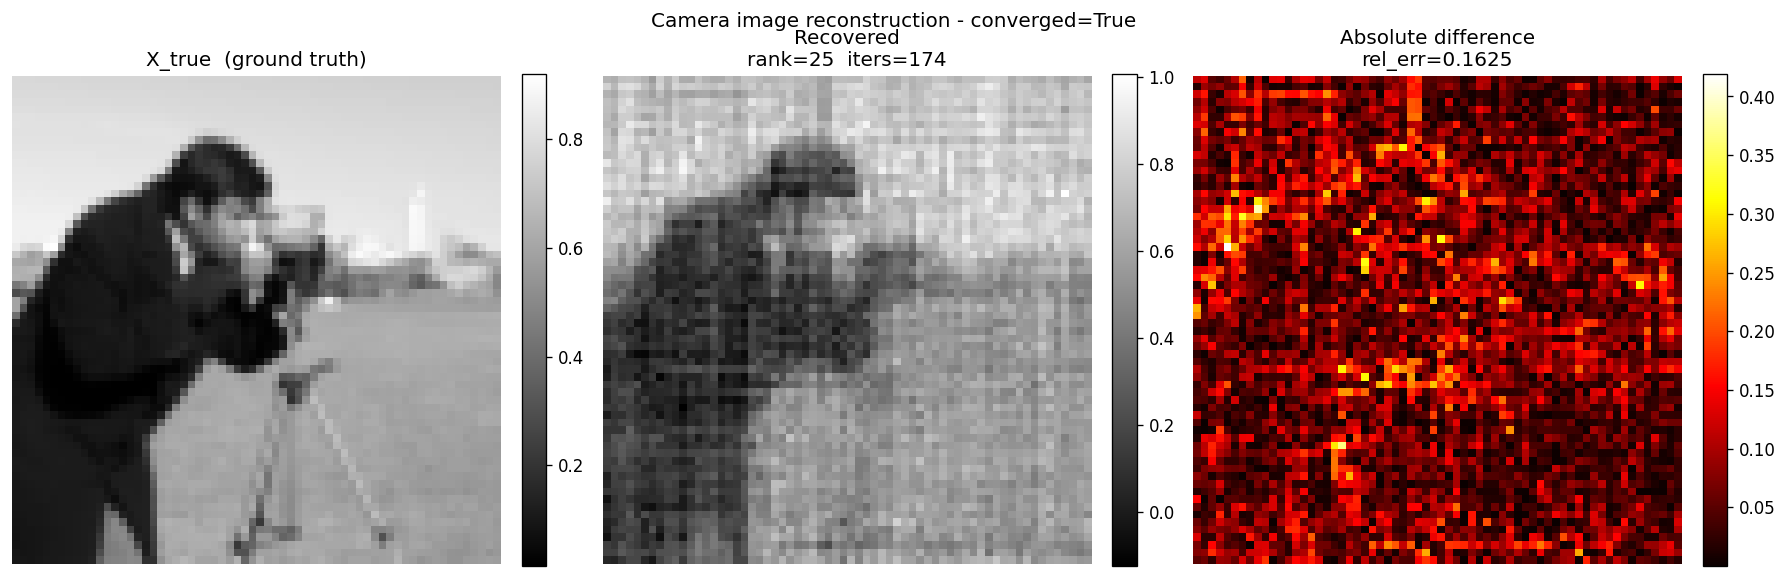


Reconstruction metrics:
Relative error : 0.162461
PSNR: 20.62 dB
SSIM: 0.432908


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

im0 = axes[0].imshow(X_true, cmap='gray')
axes[0].set_title("X_true  (ground truth)")
axes[0].axis('off')
plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

im1 = axes[1].imshow(result.X, cmap='gray')
axes[1].set_title(f"Recovered\nrank={effective_rank(result.X)}  "
                  f"iters={result.n_iters}")
axes[1].axis('off')
plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

diff    = np.abs(result.X - X_true)
rel_err = np.linalg.norm(result.X - X_true, 'fro') / np.linalg.norm(X_true, 'fro')
im2 = axes[2].imshow(diff, cmap='hot')
axes[2].set_title(f"Absolute difference\nrel_err={rel_err:.4f}")
axes[2].axis('off')
plt.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)

plt.suptitle(f"Camera image reconstruction - converged={result.converged}",
             fontsize=12)
plt.tight_layout()
plt.show()

print("\nReconstruction metrics:")
print_metrics(result.X, X_true)

# 5. Convergence diagnostics

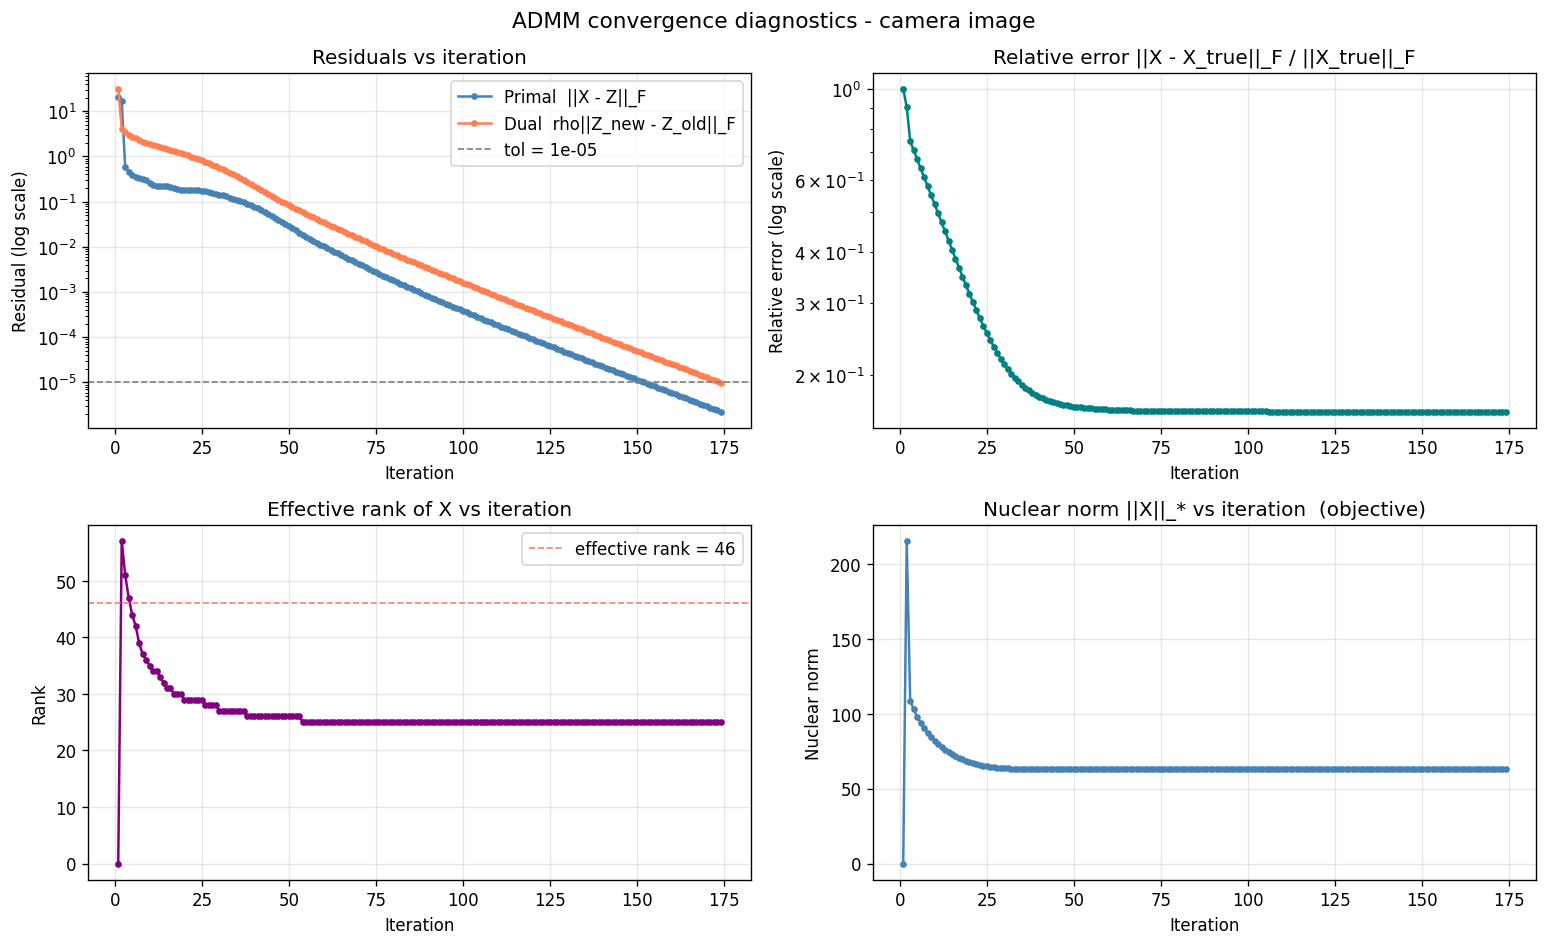

In [7]:
h     = result.history
iters = range(1, result.n_iters + 1)

fig, axes = plt.subplots(2, 2, figsize=(13, 8))

axes[0, 0].semilogy(iters, h.primal_residuals, color='steelblue',
                    linewidth=1.5, label='Primal  ||X - Z||_F', marker='.')
axes[0, 0].semilogy(iters, h.dual_residuals, color='coral',
                    linewidth=1.5, label='Dual  rho||Z_new - Z_old||_F', marker='.')
axes[0, 0].axhline(y=TOL, color='gray', linestyle='--', linewidth=1,
                   label=f'tol = {TOL}')
axes[0, 0].set_title("Residuals vs iteration")
axes[0, 0].set_xlabel("Iteration")
axes[0, 0].set_ylabel("Residual (log scale)")
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].semilogy(iters, h.rel_errors, color='teal', linewidth=1.5, marker='.')
axes[0, 1].set_title("Relative error ||X - X_true||_F / ||X_true||_F")
axes[0, 1].set_xlabel("Iteration")
axes[0, 1].set_ylabel("Relative error (log scale)")
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].plot(iters, h.ranks, color='purple', linewidth=1.5, marker='.')
axes[1, 0].axhline(y=eff_rank, color='salmon', linestyle='--', linewidth=1,
                   label=f'effective rank = {eff_rank}')
axes[1, 0].set_title("Effective rank of X vs iteration")
axes[1, 0].set_xlabel("Iteration")
axes[1, 0].set_ylabel("Rank")
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].plot(iters, h.objective_values, color='steelblue',
                linewidth=1.5, marker='.')
axes[1, 1].set_title("Nuclear norm ||X||_* vs iteration  (objective)")
axes[1, 1].set_xlabel("Iteration")
axes[1, 1].set_ylabel("Nuclear norm")
axes[1, 1].grid(True, alpha=0.3)

plt.suptitle("ADMM convergence diagnostics - camera image", fontsize=13)
plt.tight_layout()
plt.show()

# 6. Singular value recovery check

True singular values (top 10)     : [34.7688  8.2802  6.4576  4.1455  2.6579  1.9115  1.5385  1.4522  1.2781
  1.1485]
Recovered singular values (top 10): [33.389   7.2059  5.4481  3.4698  1.8455  1.3565  1.1353  0.9783  0.9582
  0.9179]

Final recovered rank (tol=1e-3)   : 25


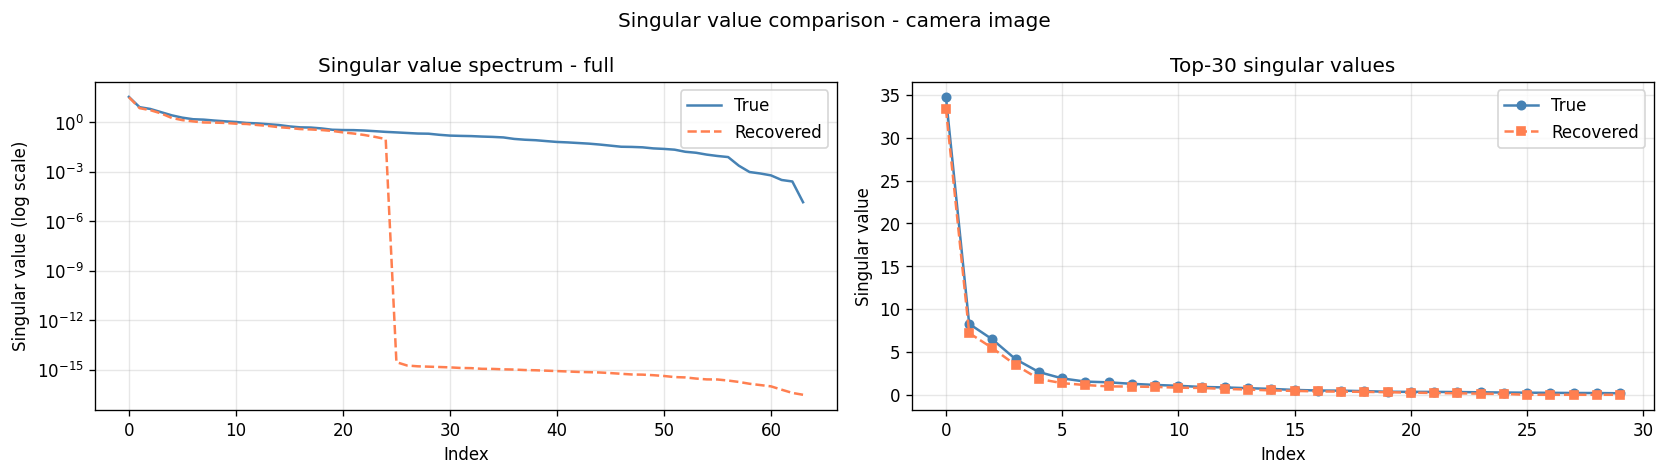

In [8]:
sigma_recovered = np.linalg.svd(result.X, compute_uv=False)

print(f"True singular values (top 10)     : {np.round(sigma[:10], 4)}")
print(f"Recovered singular values (top 10): {np.round(sigma_recovered[:10], 4)}")
print(f"\nFinal recovered rank (tol=1e-3)   : {effective_rank(result.X, tol=1e-3)}")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].semilogy(sigma, color='steelblue', linewidth=1.5, label='True')
axes[0].semilogy(sigma_recovered, color='coral', linestyle='--',
                 linewidth=1.5, label='Recovered')
axes[0].set_title("Singular value spectrum - full")
axes[0].set_xlabel("Index")
axes[0].set_ylabel("Singular value (log scale)")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

top = 30
axes[1].plot(sigma[:top], 'o-', color='steelblue', linewidth=1.5,
             markersize=5, label='True')
axes[1].plot(sigma_recovered[:top], 's--', color='coral', linewidth=1.5,
             markersize=5, label='Recovered')
axes[1].set_title(f"Top-{top} singular values")
axes[1].set_xlabel("Index")
axes[1].set_ylabel("Singular value")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle("Singular value comparison - camera image", fontsize=12)
plt.tight_layout()
plt.show()

# 7. Sampling ratio sweep

In [9]:
ratios = [0.05, 0.10, 0.20, 0.30, 0.50]
sweep  = {'rel_err': [], 'psnr': [], 'ssim': [], 'rank': []}

print(f"{'ratio':>6}  {'m':>6}  {'rel_err':>9}  {'PSNR':>8}  {'SSIM':>7}  "
      f"{'rank':>6}  {'conv':>6}")
print("-" * 60)

for ratio in ratios:
    m_r  = max(10, int(ratio * IMAGE_SIZE**2))
    op_r = MeasurementOperator(n=IMAGE_SIZE, m=m_r, seed=RANDOM_SEED)
    y_r  = op_r.measure(X_true)
    res  = admm_solve(op_r, y_r, rho=RHO, max_iter=MAX_ITER, tol=TOL, verbose=False)

    re = relative_error(res.X, X_true)
    p  = psnr(res.X, X_true)
    s  = ssim(res.X, X_true)
    rk = effective_rank(res.X)
    sweep['rel_err'].append(re)
    sweep['psnr'].append(p)
    sweep['ssim'].append(s)
    sweep['rank'].append(rk)
    print(f"{ratio:>6.2f}  {m_r:>6d}  {re:>9.5f}  {p:>8.2f}  {s:>7.4f}  "
          f"{rk:>6d}  {str(res.converged):>6}")

 ratio       m    rel_err      PSNR     SSIM    rank    conv
------------------------------------------------------------
  0.05     204    0.68167      8.38   0.0623       8   False
  0.10     409    0.44219     11.93   0.1267      13    True
  0.20     819    0.25331     16.75   0.2611      19    True
  0.30    1228    0.16246     20.62   0.4329      25    True
  0.50    2048    0.09258     25.51   0.6371      35    True


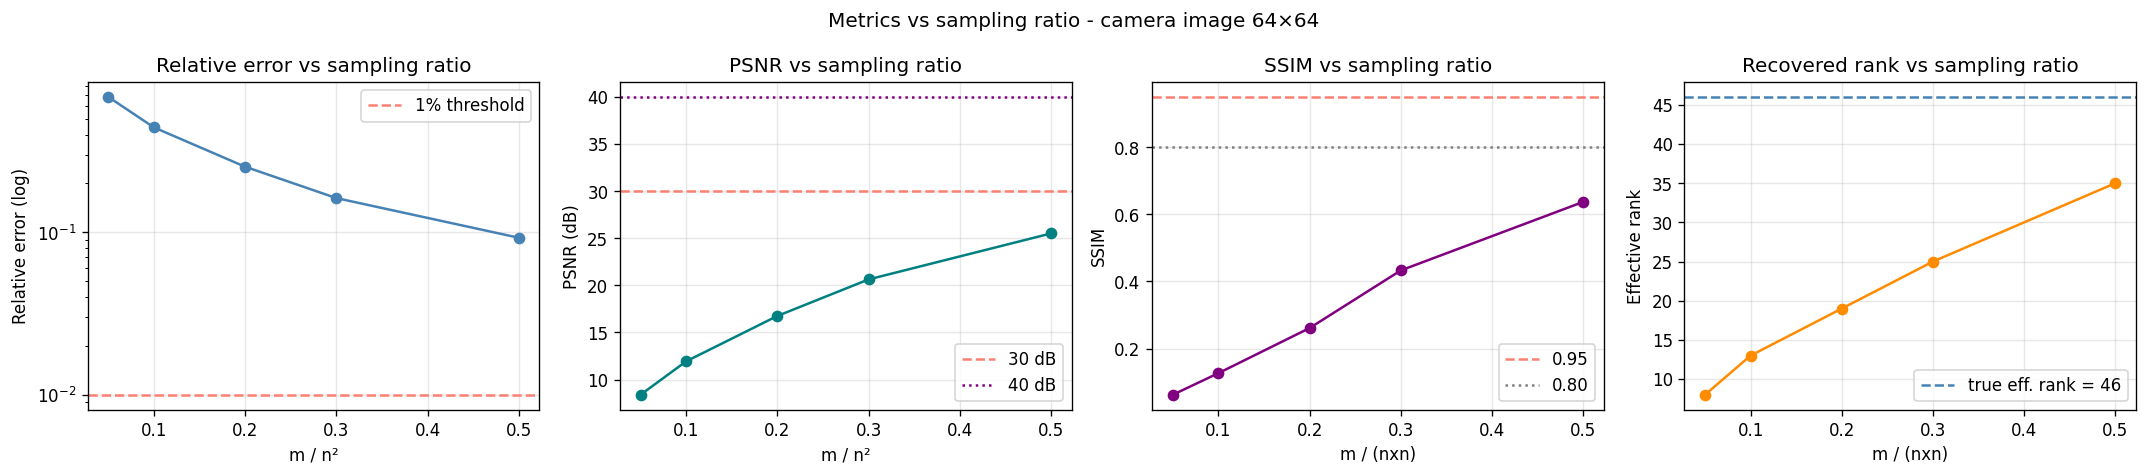

In [10]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

axes[0].semilogy(ratios, sweep['rel_err'], 'o-', color='steelblue',
                 linewidth=1.5, markersize=6)
axes[0].axhline(y=1e-2, color='salmon', linestyle='--', label='1% threshold')
axes[0].set_title("Relative error vs sampling ratio")
axes[0].set_xlabel("m / n²")
axes[0].set_ylabel("Relative error (log)")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(ratios, sweep['psnr'], 'o-', color='teal',
             linewidth=1.5, markersize=6)
axes[1].axhline(y=30, color='salmon', linestyle='--', label='30 dB')
axes[1].axhline(y=40, color='purple', linestyle=':', label='40 dB')
axes[1].set_title("PSNR vs sampling ratio")
axes[1].set_xlabel("m / n²")
axes[1].set_ylabel("PSNR (dB)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].plot(ratios, sweep['ssim'], 'o-', color='purple',
             linewidth=1.5, markersize=6)
axes[2].axhline(y=0.95, color='salmon', linestyle='--', label='0.95')
axes[2].axhline(y=0.80, color='gray', linestyle=':', label='0.80')
axes[2].set_title("SSIM vs sampling ratio")
axes[2].set_xlabel("m / (nxn)")
axes[2].set_ylabel("SSIM")
axes[2].legend()
axes[2].grid(True, alpha=0.3)

axes[3].plot(ratios, sweep['rank'], 'o-', color='darkorange',
             linewidth=1.5, markersize=6)
axes[3].axhline(y=eff_rank, color='steelblue', linestyle='--',
                label=f'true eff. rank = {eff_rank}')
axes[3].set_title("Recovered rank vs sampling ratio")
axes[3].set_xlabel("m / (nxn)")
axes[3].set_ylabel("Effective rank")
axes[3].legend()
axes[3].grid(True, alpha=0.3)

plt.suptitle(f"Metrics vs sampling ratio - camera image {IMAGE_SIZE}×{IMAGE_SIZE}",
             fontsize=12)
plt.tight_layout()
plt.show()

# 8. ρ sensitivity analysis

In [11]:
rho_values  = [0.01, 0.1, 0.5, 1.0, 5.0, 10.0]
rho_results = []

print(f"{'rho':>8}  {'iters':>7}  {'rel_err':>10}  {'PSNR':>8}  {'SSIM':>7}  {'conv':>6}")
print("-" * 55)

for rho_val in rho_values:
    res = admm_solve(op, y, rho=rho_val, max_iter=MAX_ITER, tol=TOL,
                     X_true=X_true, verbose=False)
    re = relative_error(res.X, X_true)
    p  = psnr(res.X, X_true)
    s  = ssim(res.X, X_true)
    rho_results.append((rho_val, res.n_iters, re, p, s, res.converged, res.history))
    print(f"{rho_val:>8.3f}  {res.n_iters:>7d}  {re:>10.6f}  {p:>8.2f}  "
          f"{s:>7.4f}  {str(res.converged):>6}")

     rho    iters     rel_err      PSNR     SSIM    conv
-------------------------------------------------------
   0.010     1000    0.162170     20.64   0.4335   False
   0.100      824    0.162461     20.62   0.4329    True
   0.500      165    0.162461     20.62   0.4329    True
   1.000      105    0.162461     20.62   0.4329    True
   5.000      609    0.162461     20.62   0.4329    True
  10.000     1000    0.162464     20.62   0.4329   False


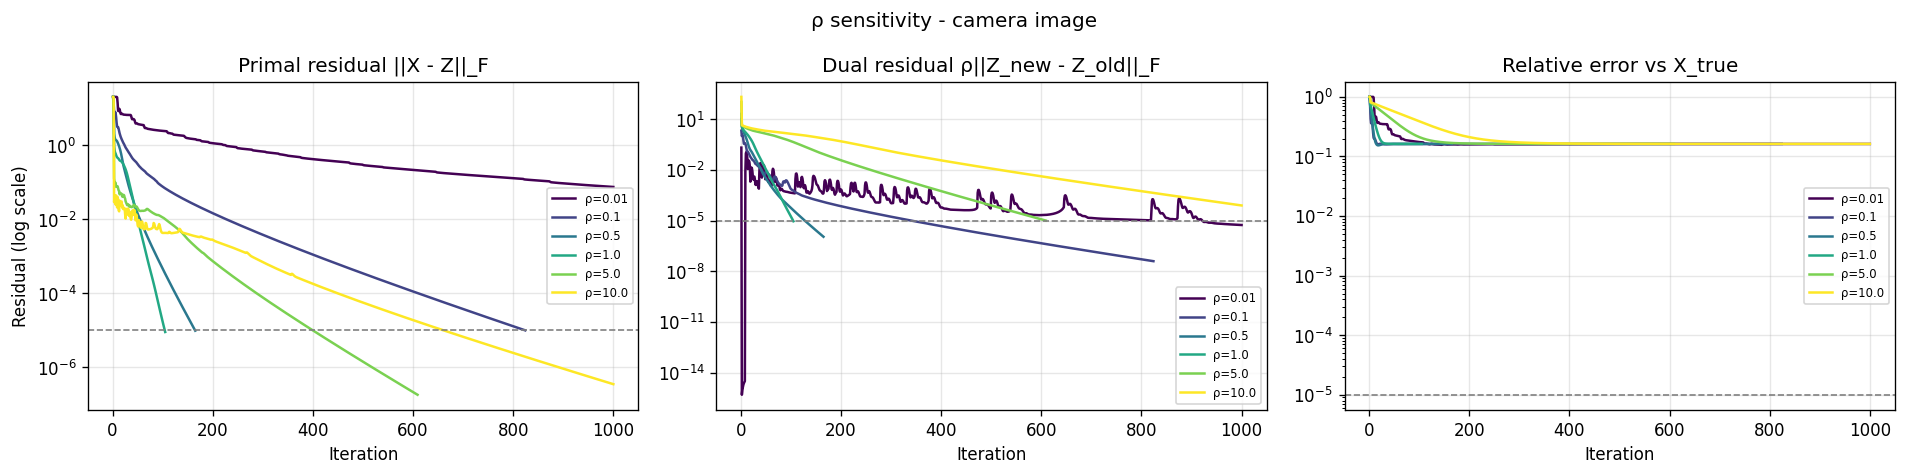

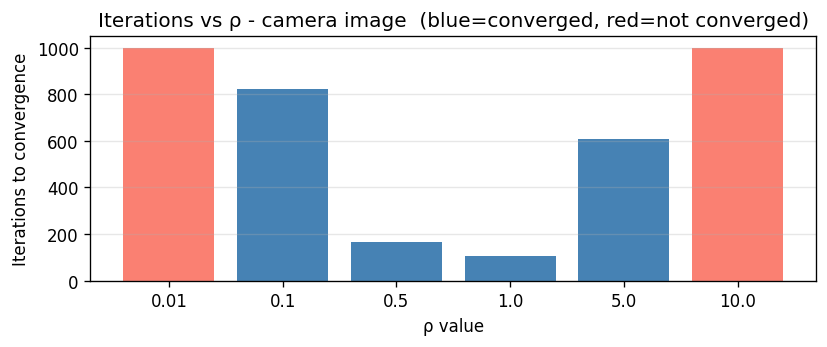

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
colors = plt.cm.viridis(np.linspace(0, 1, len(rho_values)))

for i, (rho_val, n_iters, re, p, s, conv, hist) in enumerate(rho_results):
    iters_r = range(1, n_iters + 1)
    axes[0].semilogy(iters_r, hist.primal_residuals, color=colors[i],
                     linewidth=1.5, label=f'ρ={rho_val}')
    axes[1].semilogy(iters_r, hist.dual_residuals, color=colors[i],
                     linewidth=1.5, label=f'ρ={rho_val}')
    if hist.rel_errors:
        axes[2].semilogy(iters_r, hist.rel_errors, color=colors[i],
                         linewidth=1.5, label=f'ρ={rho_val}')

for ax in axes:
    ax.axhline(y=TOL, color='gray', linestyle='--', linewidth=1)
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)
    ax.set_xlabel("Iteration")

axes[0].set_title("Primal residual ||X - Z||_F")
axes[0].set_ylabel("Residual (log scale)")
axes[1].set_title("Dual residual ρ||Z_new - Z_old||_F")
axes[2].set_title("Relative error vs X_true")

plt.suptitle("ρ sensitivity - camera image", fontsize=12)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(7, 3))
ax.bar([str(r[0]) for r in rho_results],
       [r[1] for r in rho_results],
       color=['steelblue' if r[5] else 'salmon' for r in rho_results])
ax.set_xlabel("ρ value")
ax.set_ylabel("Iterations to convergence")
ax.set_title("Iterations vs ρ - camera image  (blue=converged, red=not converged)")
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

# 9. Cross-dataset summary table
Consolidate final metrics across all three settings at a fixed 30% sampling ratio 
for a direct apples-to-apples comparison.

In [13]:
from config import IMAGE_SIZE as SL_SIZE, N_MEASUREMENTS as SL_M

# --- Toy (rank-2, n=20) ---
n_toy   = 20
r_toy   = 2
m_toy   = int(0.30 * n_toy**2)
rng_toy = np.random.default_rng(42)
U_t = rng_toy.standard_normal((n_toy, r_toy))
V_t = rng_toy.standard_normal((n_toy, r_toy))
X_toy = U_t @ V_t.T
# Normalise toy to [0,1] for fair metric comparison
X_toy_norm = (X_toy - X_toy.min()) / (X_toy.max() - X_toy.min())
op_toy = MeasurementOperator(n=n_toy, m=m_toy, seed=42)
y_toy  = op_toy.measure(X_toy_norm)
res_toy = admm_solve(op_toy, y_toy, verbose=False)

# --- Shepp-Logan ---
X_sl   = np.load(SHEPP_LOGAN_PATH)
m_sl   = int(0.30 * SL_SIZE**2)
op_sl  = MeasurementOperator(n=SL_SIZE, m=m_sl, seed=RANDOM_SEED)
y_sl   = op_sl.measure(X_sl)
res_sl = admm_solve(op_sl, y_sl, verbose=False)

# --- Camera ---
m_cam  = int(0.30 * IMAGE_SIZE**2)
op_cam = MeasurementOperator(n=IMAGE_SIZE, m=m_cam, seed=RANDOM_SEED)
y_cam  = op_cam.measure(X_true)
res_cam = admm_solve(op_cam, y_cam, verbose=False)

print("=" * 80)
print("Cross-dataset summary  |  sampling ratio = 30%")
print("=" * 80)
print(f"{'Dataset':<20}  {'n':>4}  {'eff_rank':>8}  {'rel_err':>9}  "
      f"{'PSNR':>8}  {'SSIM':>7}  {'iters':>6}  {'conv':>6}")
print("-" * 80)

datasets = [
    ("Toy rank-2",    X_toy_norm, res_toy, n_toy,       2),
    ("Shepp-Logan",   X_sl,       res_sl,  SL_SIZE,
     np.sum(np.linalg.svd(X_sl, compute_uv=False) > np.linalg.svd(X_sl, compute_uv=False)[0]*1e-3)),
    ("Camera image",  X_true,     res_cam, IMAGE_SIZE,  eff_rank),
]

for name, X_ref, res, n_ds, er in datasets:
    re = relative_error(res.X, X_ref)
    p  = psnr(res.X, X_ref)
    s  = ssim(res.X, X_ref)
    print(f"{name:<20}  {n_ds:>4}  {er:>8}  {re:>9.5f}  "
          f"{p:>8.2f}  {s:>7.4f}  {res.n_iters:>6}  {str(res.converged):>6}")

print("=" * 80)

Cross-dataset summary  |  sampling ratio = 30%
Dataset                  n  eff_rank    rel_err      PSNR     SSIM   iters    conv
--------------------------------------------------------------------------------
Toy rank-2              20         2    0.21849     19.74   0.6324      97    True
Shepp-Logan            128        67    0.36839     21.84   0.3342     182    True
Camera image            64        46    0.16246     20.62   0.4329     174    True
